**Step 1: Data Collection**

In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("banking_collections_dataset.csv")

In [3]:
dataset

,Customer_ID,Name,Account_Number,Account_Type,Loan_Type,Loan_Amount,Outstanding_Amount,EMI_Amount,Due_Date,Payment_Status,Collection_Agent,Last_Payment_Date,Payment_Delay_Days,Region,Contact_Number,Email,Customer_Score,Risk_Level
0,CUST00000,Richard Mccarty,81087F51-C9F,Current,Car Loan,299783,119495.19,2597.72,2023-12-05,Paid,Tyler Copeland,2023-10-06,0,West,001-713-059-9538x4286,diane22@gmail.com,557,Medium
1,CUST00001,Patrick Kane,819326DB-44D,Current,Home Loan,46987,37830.59,1576.27,2023-04-07,Paid,Lindsey Doyle,2023-03-20,0,South,001-118-785-4275,edward97@yahoo.com,500,High
2,CUST00002,Jean Morgan,A8682A8D-986,Current,Home Loan,259917,112988.74,4035.31,2024-10-31,Missed,Shawna Smith,NaN,43,East,+1-158-183-9055,ifranklin@gmail.com,342,High
3,CUST00003,Michael Green,45516DAD-9C8,Credit,Personal Loan,198807,122047.34,3698.40,2024-01-23,Partially Paid,Peter Miller,2023-11-10,84,South,828-258-5077,craig92@franklin-lindsey.com,806,Low
4,CUST00004,Tony Greene,18D78B45-41D,Savings,Home Loan,411507,113899.82,3254.28,2023-05-10,Partially Paid,Erin Moore,2023-04-11,31,North,(611)277-3109x276,obaker@peterson.com,755,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,CUST00995,Lucas Ingram,6717D08D-8BF,Savings,Car Loan,308726,98191.86,5455.10,2024-05-08,Missed,Brittney King,NaN,73,North,+1-684-628-7728x808,ohodge@hotmail.com,386,High
996,CUST00996,Matthew Tran,30158651-FF0,Current,Car Loan,145881,42105.25,1203.01,2023-07-25,Paid,Elizabeth Hess DDS,2023-05-26,0,South,147-363-0896x130,murphydominique@yahoo.com,387,High
997,CUST00997,Robert Martinez,0B84F5D6-0E4,Current,Home Loan,293449,28638.37,520.70,2023-03-05,Partially Paid,Charles Kline,2023-01-29,73,West,341.723.5709x3350,jjackson@yahoo.com,751,Low
998,CUST00998,Kimberly Ramirez,5E254A28-AF8,Savings,Personal Loan,492815,201018.27,6484.46,2023-09-29,Missed,Gerald Anderson,NaN,62,North,(226)320-5961x06171,katherineporter@gmail.com,755,Low


In [4]:
print(dataset.head())

  Customer_ID             Name Account_Number Account_Type      Loan_Type  \
0   CUST00000  Richard Mccarty   81087F51-C9F      Current       Car Loan   
1   CUST00001     Patrick Kane   819326DB-44D      Current      Home Loan   
2   CUST00002      Jean Morgan   A8682A8D-986      Current      Home Loan   
3   CUST00003    Michael Green   45516DAD-9C8       Credit  Personal Loan   
4   CUST00004      Tony Greene   18D78B45-41D      Savings      Home Loan   

   Loan_Amount  Outstanding_Amount  EMI_Amount    Due_Date  Payment_Status  \
0       299783           119495.19     2597.72  2023-12-05            Paid   
1        46987            37830.59     1576.27  2023-04-07            Paid   
2       259917           112988.74     4035.31  2024-10-31          Missed   
3       198807           122047.34     3698.40  2024-01-23  Partially Paid   
4       411507           113899.82     3254.28  2023-05-10  Partially Paid   

  Collection_Agent Last_Payment_Date  Payment_Delay_Days Region  \
0

In [5]:
print(dataset.shape)

(1000, 18)


In [6]:
print(dataset.columns)

Index(['Customer_ID', 'Name', 'Account_Number', 'Account_Type', 'Loan_Type',
       'Loan_Amount', 'Outstanding_Amount', 'EMI_Amount', 'Due_Date',
       'Payment_Status', 'Collection_Agent', 'Last_Payment_Date',
       'Payment_Delay_Days', 'Region', 'Contact_Number', 'Email',
       'Customer_Score', 'Risk_Level'],
      dtype='str')


**Project Objective**

**Predict EMI collection risk level (Low, Medium, High) to help banks prioritize collection activities.**

**Step 2: Data Preprocessing**

**Dataset Information**

In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   str    
 1   Name                1000 non-null   str    
 2   Account_Number      1000 non-null   str    
 3   Account_Type        1000 non-null   str    
 4   Loan_Type           1000 non-null   str    
 5   Loan_Amount         1000 non-null   int64  
 6   Outstanding_Amount  1000 non-null   float64
 7   EMI_Amount          1000 non-null   float64
 8   Due_Date            1000 non-null   str    
 9   Payment_Status      1000 non-null   str    
 10  Collection_Agent    1000 non-null   str    
 11  Last_Payment_Date   655 non-null    str    
 12  Payment_Delay_Days  1000 non-null   int64  
 13  Region              1000 non-null   str    
 14  Contact_Number      1000 non-null   str    
 15  Email               1000 non-null   str    
 16  Customer_Score    

**Missing values**

In [8]:
dataset.isnull().sum()

Customer_ID             0
Name                    0
Account_Number          0
Account_Type            0
Loan_Type               0
Loan_Amount             0
Outstanding_Amount      0
EMI_Amount              0
Due_Date                0
Payment_Status          0
Collection_Agent        0
Last_Payment_Date     345
Payment_Delay_Days      0
Region                  0
Contact_Number          0
Email                   0
Customer_Score          0
Risk_Level              0
dtype: int64

In [9]:
dataset.drop(['Due_Date', 'Last_Payment_Date'], axis=1, inplace=True)

In [10]:
dataset.isnull().sum()

Customer_ID           0
Name                  0
Account_Number        0
Account_Type          0
Loan_Type             0
Loan_Amount           0
Outstanding_Amount    0
EMI_Amount            0
Payment_Status        0
Collection_Agent      0
Payment_Delay_Days    0
Region                0
Contact_Number        0
Email                 0
Customer_Score        0
Risk_Level            0
dtype: int64

**Duplicate Records**

In [11]:
dataset.duplicated().sum()
dataset.drop_duplicates(inplace=True)

**Remove Unnecessary Columns**

Check actual column names

In [12]:
print(dataset.columns.tolist())

['Customer_ID', 'Name', 'Account_Number', 'Account_Type', 'Loan_Type', 'Loan_Amount', 'Outstanding_Amount', 'EMI_Amount', 'Payment_Status', 'Collection_Agent', 'Payment_Delay_Days', 'Region', 'Contact_Number', 'Email', 'Customer_Score', 'Risk_Level']


Safely drop columns

In [13]:
dataset.drop(
    [
        'Customer_ID',
        'Name',
        'Account_Number',
        'Contact_Number',
        'Email',
        'Collection_Agent',
        'Due_Date',
        'Last_Payment_Date'
    ],
    axis=1,
    errors='ignore',
    inplace=True
)

Verify remaining columns

In [14]:
print(dataset.columns.tolist())

['Account_Type', 'Loan_Type', 'Loan_Amount', 'Outstanding_Amount', 'EMI_Amount', 'Payment_Status', 'Payment_Delay_Days', 'Region', 'Customer_Score', 'Risk_Level']


Check missing values again

In [15]:
print(dataset.isnull().sum())

Account_Type          0
Loan_Type             0
Loan_Amount           0
Outstanding_Amount    0
EMI_Amount            0
Payment_Status        0
Payment_Delay_Days    0
Region                0
Customer_Score        0
Risk_Level            0
dtype: int64


**Encode Categorical Columns**

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Account_Type',
    'Loan_Type',
    'Payment_Status',
    'Region',
    'Risk_Level'
]

for col in categorical_cols:
    dataset[col] = le.fit_transform(dataset[col])

**Step 3: Univariate & Bivariate Analysis**

**Univariate Analysis**

**EMI Amount Distribution**

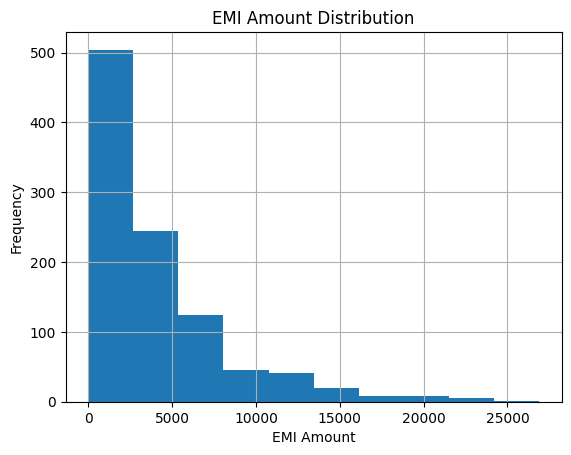

In [17]:
import matplotlib.pyplot as plt  #How many customers pay high and Low EMI amounts?

dataset['EMI_Amount'].hist()

plt.title("EMI Amount Distribution")
plt.xlabel("EMI Amount")      # X-axis title
plt.ylabel("Frequency")       # Y-axis title

plt.show()

**Customer Score Distribution**

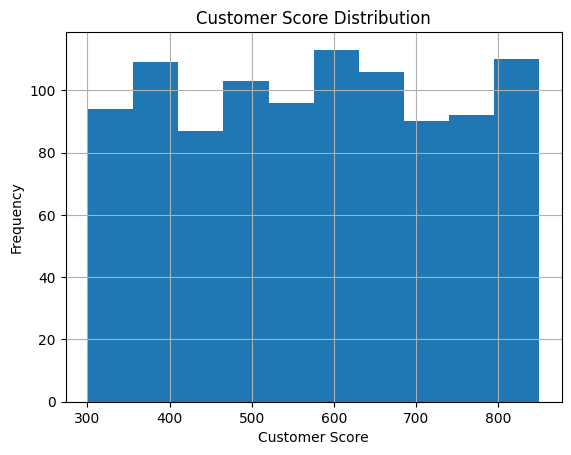

In [18]:
import matplotlib.pyplot as plt  #Analysis of Customer Credit Scores

dataset['Customer_Score'].hist()

plt.title("Customer Score Distribution")
plt.xlabel("Customer Score")      # X-axis title
plt.ylabel("Frequency")           # Y-axis title

plt.show()

**Risk Level Count**

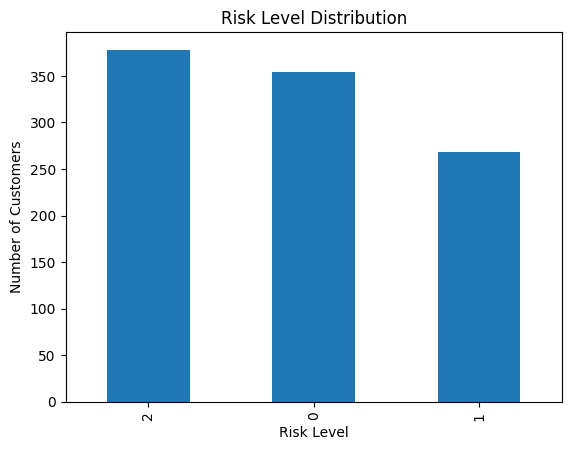

In [19]:
dataset['Risk_Level'].value_counts().plot(kind='bar') #0-Low Risk, 1-medium Risk, 2-High Risk.

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")          # X-axis title
plt.ylabel("Number of Customers") # Y-axis title

plt.show()

**Bivariate Analysis**

**Customer Score vs Risk Level**

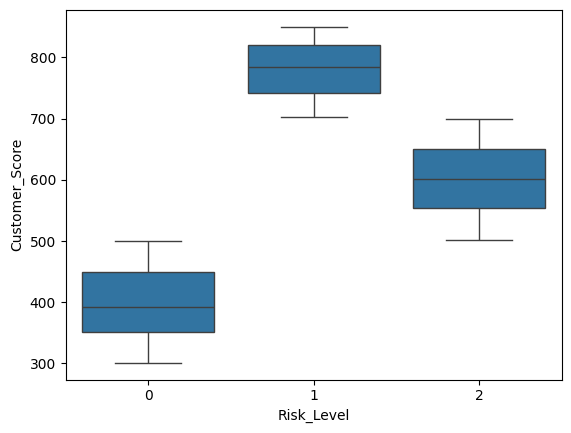

In [20]:
import seaborn as sns #Does a lower Customer Score indicate a higher risk?

sns.boxplot(
    x='Risk_Level',
    y='Customer_Score',
    data=dataset
)
plt.show()

**Payment Delay Days vs Risk Level**

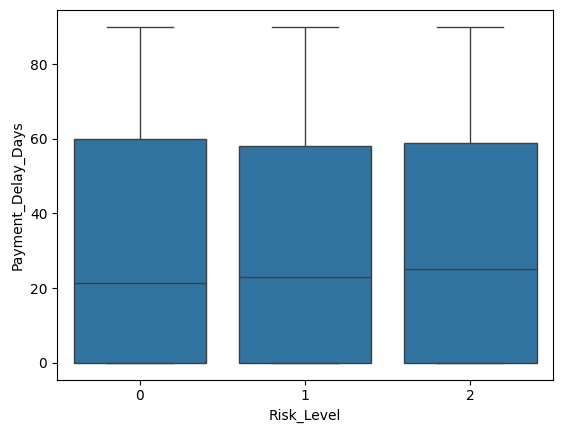

In [21]:
sns.boxplot(                          #Does the risk increase as EMI Delay Days increase?
    x='Risk_Level',
    y='Payment_Delay_Days',
    data=dataset
)
plt.show()

**Outstanding Amount vs Risk Level**

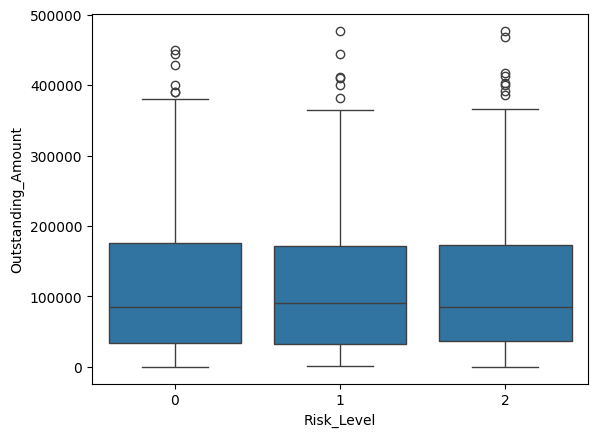

In [22]:
sns.boxplot(                                    #Is the Outstanding Amount high?
    x='Risk_Level',
    y='Outstanding_Amount',
    data=dataset
)
plt.show()

**Step 4: Feature Selection & Model Creation**

**Feature Selection**

In [23]:
X = dataset.drop('Risk_Level', axis=1) #x-Input datas independent variables

y = dataset['Risk_Level']              #Y-Output datas Dependent variables

**Train Test Split**

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Use only X_test
print(y_test)

521    0
737    0
740    1
660    1
411    2
      ..
408    0
332    0
208    2
613    2
78     1
Name: Risk_Level, Length: 200, dtype: int64


**Model Creation**

**Logistic Regression**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression:", acc_lr)

Logistic Regression: 0.475


C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Decision Tree**

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree:", acc_dt)

Decision Tree: 1.0


**Random Forest**

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest:", acc_rf)

Random Forest: 1.0


**Model Comparison**

In [28]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        acc_lr,
        acc_dt,
        acc_rf
    ]
})

results['Accuracy %'] = results['Accuracy'] * 100

print(results)

                 Model  Accuracy  Accuracy %
0  Logistic Regression     0.475        47.5
1        Decision Tree     1.000       100.0
2        Random Forest     1.000       100.0


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print(dt.predict(X_test.iloc[[100]]))

[2]


**Step 5: Final Model**

**Classification Report**

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        73

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [33]:
risk_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}

pred = dt.predict(X_test)

pred_labels = [risk_map[i] for i in pred]

print(pred_labels[:10])

['Low Risk', 'Low Risk', 'Medium Risk', 'Medium Risk', 'High Risk', 'High Risk', 'Low Risk', 'High Risk', 'Medium Risk', 'High Risk']


In [34]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

**Save Final Model**

**(Decision Tree is your best model)**

In [35]:
import pickle
# Risk label mapping
risk_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}

# Save both model and mapping
model_package = {
    "model": dt,
    "risk_map": risk_map
}

with open("emi_collection_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("Model Saved Successfully")
print("Classes learned:", dt.classes_)

Model Saved Successfully
Classes learned: [0 1 2]


**Load Saved Model**

In [36]:
import pickle

# Load saved package
with open("emi_collection_model.pkl", "rb") as file:
    saved_data = pickle.load(file)

# Extract model and mapping
model = saved_data["model"]
risk_map = saved_data["risk_map"]

# Prediction
pred = model.predict(X_test)

print("Raw Prediction:")
print(pred)

# Convert numbers to labels
risk_prediction = [risk_map[i] for i in pred]

print("Risk Prediction:")
print(risk_prediction)

Raw Prediction:
[0 0 1 1 2 2 0 2 1 2 0 1 2 1 2 0 1 2 0 1 0 2 2 1 2 2 2 1 1 1 2 1 0 2 2 2 0
 1 0 0 2 0 0 0 0 1 2 1 2 0 2 2 2 1 2 1 0 0 1 0 1 0 0 0 1 0 0 0 2 1 1 1 2 0
 1 2 2 1 1 2 1 1 0 1 2 2 1 0 1 1 2 2 0 0 2 2 0 0 1 2 2 1 2 2 1 2 0 1 0 2 0
 1 2 1 2 0 1 0 0 1 0 2 1 2 1 1 1 0 1 2 2 0 0 0 2 0 1 2 1 1 2 0 2 2 1 1 2 0
 0 2 2 0 1 0 0 2 2 1 0 0 2 2 0 2 1 0 2 1 2 0 1 0 2 0 1 0 2 2 2 2 0 2 1 1 2
 2 0 0 0 1 0 2 0 2 0 0 0 2 2 1]
Risk Prediction:
['Low Risk', 'Low Risk', 'Medium Risk', 'Medium Risk', 'High Risk', 'High Risk', 'Low Risk', 'High Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'High Risk', 'High Risk', 'Medium Risk', 'High Risk', 'High Risk', 'High Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'Low Risk', 'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'High Risk', 'Low Risk',

In [37]:
risk_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}

risk_prediction = [risk_map[i] for i in pred]

print(risk_prediction)

['Low Risk', 'Low Risk', 'Medium Risk', 'Medium Risk', 'High Risk', 'High Risk', 'Low Risk', 'High Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'High Risk', 'High Risk', 'Medium Risk', 'High Risk', 'High Risk', 'High Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'Low Risk', 'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'High Risk', 'High Risk', 'High Risk', 'Medium Risk', 'High Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'High Risk', 'Medium Risk', 'Medium Risk', 'Medium Risk', 'High Risk', 'Low Risk', 'Medium Risk', 'H

In [38]:
predictions = model.predict(X_test)

print(pd.Series(predictions).value_counts())

2    73
0    67
1    60
Name: count, dtype: int64


In [39]:
print(dataset['Risk_Level'].value_counts())

Risk_Level
2    378
0    354
1    268
Name: count, dtype: int64


In [40]:
sample = X_test.iloc[[0]]
print(model.predict(sample))

[0]


In [41]:
for i in range(10):
    print(model.predict(X_test.iloc[[i]]))

[0]
[0]
[1]
[1]
[2]
[2]
[0]
[2]
[1]
[2]


In [42]:
print(dataset['Risk_Level'].unique())

[2 0 1]


In [43]:
print(le.classes_)

['High' 'Low' 'Medium']


In [44]:
print(y_train.value_counts())
print(y_test.value_counts())

Risk_Level
2    305
0    287
1    208
Name: count, dtype: int64
Risk_Level
2    73
0    67
1    60
Name: count, dtype: int64


In [45]:
print(dataset['Risk_Level'].value_counts())

print(y_train.value_counts())

print(pd.Series(model.predict(X_test)).value_counts())

Risk_Level
2    378
0    354
1    268
Name: count, dtype: int64
Risk_Level
2    305
0    287
1    208
Name: count, dtype: int64
2    73
0    67
1    60
Name: count, dtype: int64


In [46]:
print(dataset['Risk_Level'].value_counts())

Risk_Level
2    378
0    354
1    268
Name: count, dtype: int64


In [47]:
print(dataset[['Risk_Level']].head(20))

    Risk_Level
0            2
1            0
2            0
3            1
4            1
5            1
6            2
7            1
8            0
9            1
10           0
11           1
12           2
13           2
14           1
15           0
16           2
17           2
18           2
19           1


In [48]:
print(X.columns.tolist())

['Account_Type', 'Loan_Type', 'Loan_Amount', 'Outstanding_Amount', 'EMI_Amount', 'Payment_Status', 'Payment_Delay_Days', 'Region', 'Customer_Score']


In [49]:
dataset.head()

,Account_Type,Loan_Type,Loan_Amount,Outstanding_Amount,EMI_Amount,Payment_Status,Payment_Delay_Days,Region,Customer_Score,Risk_Level
0,1,0,299783,119495.19,2597.72,1,0,3,557,2
1,1,1,46987,37830.59,1576.27,1,0,2,500,0
2,1,1,259917,112988.74,4035.31,0,43,0,342,0
3,0,2,198807,122047.34,3698.40,2,84,2,806,1
4,2,1,411507,113899.82,3254.28,2,31,1,755,1


In [66]:
import pickle

loaded_data = pickle.load(open("emi_collection_model.pkl", "rb"))

loaded_model = loaded_data["model"]

print(loaded_model.predict(X_test.iloc[[1]]))
print(loaded_model.predict(X_test.iloc[[50]]))

[0]
[2]


In [67]:
print(type(dt))

<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [68]:
print(dt.predict(X_test.iloc[[0]]))
print(dt.predict(X_test.iloc[[1]]))
print(dt.predict(X_test.iloc[[45]]))

[0]
[0]
[1]


In [69]:
print(y_train.value_counts())

Risk_Level
2    305
0    287
1    208
Name: count, dtype: int64


In [70]:
import numpy as np
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2]), array([287, 208, 305]))


In [71]:
print(dt.score(X_train, y_train))
print(dt.score(X_test, y_test))

1.0
1.0


In [72]:
print(dt.classes_)
print(y_train.value_counts())

[0 1 2]
Risk_Level
2    305
0    287
1    208
Name: count, dtype: int64
